# Lecture 8: Stabilisation Policy

**Macroeconomics B, Chapter 20**

By the end of this notebook you will be able to:
1. Compute the AD curve implied by a Taylor rule.
2. Compare demand shocks and supply shocks in the AS-AD model.
3. Calculate the optimal policy response to an adverse supply shock.
4. Simulate inflation persistence under static expectations.
5. Compare fiscal policy in normal times and at the lower bound.

**Table of contents**<a id='toc0_'></a>
- 1. [Notebook map and calibration](#toc1_)
- 2. [Taylor-rule AD and shock types](#toc2_)
  - 2.1. [Try it yourself](#toc2_1_)
- 3. [Optimal response to a supply shock](#toc3_)
- 4. [Static expectations and persistence](#toc4_)
- 5. [Real data: Denmark inflation and policy rates](#toc5_)
- 6. [Fiscal policy at the lower bound](#toc6_)
- 7. [Group exercise](#toc7_)
- 8. [Summary](#toc8_)

In [1]:
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

# Global plot settings (matches reference course style)
plt.rcParams.update({'axes.grid': True, 'grid.color': 'black',
                     'grid.alpha': 0.25, 'grid.linestyle': '--'})
plt.rcParams.update({'font.size': 14})

# Reproducibility
rng = np.random.default_rng(2025)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

## 1. <a id='toc1_'></a>[Notebook map and calibration](#toc0_)

| Section | Model object | Purpose |
|---|---|---|
| 2. Taylor-rule AD | $\widehat y_t=z_t-a(\pi_t-\pi^*)$ | See how $h$ and $b$ shape stabilisation. |
| 3. Optimal policy | $\min_{\widehat y_t}\widehat y_t^2+\kappa(\gamma\widehat y_t+s_t)^2$ | Compute the output-inflation trade-off after a supply shock. |
| 4. Persistence | static expectations | Show how current inflation moves next period's AS curve. |
| 5. Real data | Danish HICP and policy rates | Link the model to the recent inflation and tightening episode. |
| 6. Lower bound | normal AD versus trap AD | Compare fiscal multipliers when monetary policy is constrained. |

The baseline parameters are chosen for transparency rather than estimation. They make the model easy to interpret: one unit is one percentage point, and all variables are gaps around their reference values.

In [2]:
# === Baseline parameters ===
par = {
    'gamma': 0.50,   # AS slope
    'kappa': 2.00,   # inflation weight in social loss
    'alpha2': 1.50,  # IS sensitivity to the real interest rate
    'h': 1.00,       # Taylor-rule response to inflation
    'b': 0.50,       # Taylor-rule response to the output gap
}

def ad_parameters(p):
    '''Return the Taylor-rule AD parameters a and z for a demand shock.'''
    a = p['alpha2'] * p['h'] / (1.0 + p['alpha2'] * p['b'])
    return a


def equilibrium_as_ad(p, z=0.0, s=0.0, pi_e_gap=0.0, a=None):
    '''Solve AS and AD for output gap and inflation gap.'''
    gamma = p['gamma']
    if a is None:
        a = ad_parameters(p)
    pi_gap = (pi_e_gap + gamma * z + s) / (1.0 + a * gamma)
    x = z - a * pi_gap
    return x, pi_gap


def social_loss(x, pi_gap, p):
    '''Return the one-period social loss.'''
    return x ** 2 + p['kappa'] * pi_gap ** 2


def optimal_supply_response(p, s):
    '''Return the one-period optimal response to a supply shock.'''
    gamma = p['gamma']
    kappa = p['kappa']
    x_star = -gamma * kappa / (1.0 + gamma ** 2 * kappa) * s
    pi_star = 1.0 / (1.0 + gamma ** 2 * kappa) * s
    return x_star, pi_star


a_base = ad_parameters(par)
print(f"Baseline AD slope parameter a = {a_base:.3f}")

Baseline AD slope parameter a = 0.857


The parameter $a$ is the policy-induced sensitivity of demand to inflation. A larger $a$ means a flatter AD curve in $(y,\pi)$ space and a stronger disinflationary response to inflation.

## 2. <a id='toc2_'></a>[Taylor-rule AD and shock types](#toc0_)

The same policy rule behaves differently depending on the shock. A positive demand shock shifts AD. A positive supply shock shifts AS. The model equations are

$$\widehat y_t=z_t-a\widehat\pi_t,\qquad \widehat\pi_t=\pi_t^e-\pi^*+\gamma\widehat y_t+s_t,$$

where $\widehat y_t=y_t-\bar y$ and $\widehat\pi_t=\pi_t-\pi^*$.

In [3]:
# === Compare weak and strong Taylor-rule responses ===
shock_par = dict(par)
a_values = {
    'weak response': 0.25,
    'baseline response': ad_parameters(shock_par),
    'strong response': 2.50,
}
shock_size = 2.0
rows = []
for label, a_val in a_values.items():
    x_d, pi_d = equilibrium_as_ad(shock_par, z=shock_size, s=0.0, a=a_val)
    x_s, pi_s = equilibrium_as_ad(shock_par, z=0.0, s=shock_size, a=a_val)
    rows.append({'policy': label, 'shock': 'demand', 'x': x_d,
                 'pi_gap': pi_d, 'loss': social_loss(x_d, pi_d, shock_par)})
    rows.append({'policy': label, 'shock': 'supply', 'x': x_s,
                 'pi_gap': pi_s, 'loss': social_loss(x_s, pi_s, shock_par)})

shock_table = pd.DataFrame(rows)
shock_table.round(3)

,policy,shock,x,pi_gap,loss
0,weak response,demand,1.778,0.889,4.741
1,weak response,supply,-0.444,1.778,6.519
2,baseline response,demand,1.400,0.700,2.940
3,baseline response,supply,-1.200,1.400,5.360
4,strong response,demand,0.889,0.444,1.185
5,strong response,supply,-2.222,0.889,6.519


For demand shocks, stronger policy tends to reduce both gaps. For supply shocks, stronger policy lowers the inflation gap by making the output gap more negative.

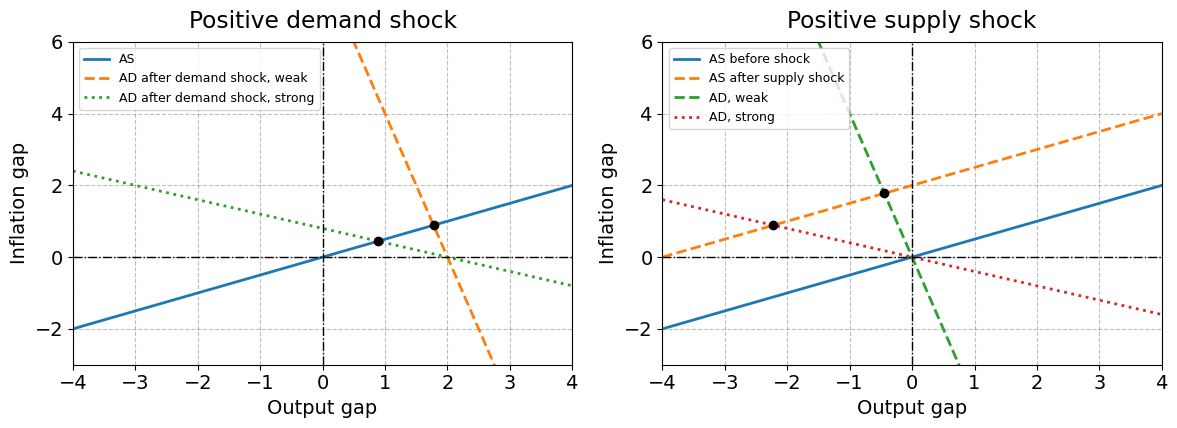

In [4]:
# === AS-AD diagrams for demand and supply shocks ===
x_grid = np.linspace(-4, 4, 200)
gamma = par['gamma']
pi_star_gap = 0.0

fig = plt.figure(figsize=(12, 4.5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

# Panel 1: demand shock, AS unchanged, AD shifts
ax1.plot(x_grid, gamma * x_grid, ls='-', lw=2, label='AS')
for label, a_val, ls in [('weak', 0.25, '--'), ('strong', 2.50, ':')]:
    pi_ad = (shock_size - x_grid) / a_val
    ax1.plot(x_grid, pi_ad, ls=ls, lw=2, label=f'AD after demand shock, {label}')
    x_eq, pi_eq = equilibrium_as_ad(par, z=shock_size, s=0.0, a=a_val)
    ax1.scatter([x_eq], [pi_eq], color='black', zorder=5)
ax1.axhline(0, color='black', lw=1, ls='-.')
ax1.axvline(0, color='black', lw=1, ls='-.')
ax1.set_title('Positive demand shock', pad=10)
ax1.set_xlabel('Output gap')
ax1.set_ylabel('Inflation gap')
ax1.set_xlim(-4, 4)
ax1.set_ylim(-3, 6)
ax1.legend(fontsize=9)

# Panel 2: supply shock, AS shifts upward
ax2.plot(x_grid, gamma * x_grid, ls='-', lw=2, label='AS before shock')
ax2.plot(x_grid, gamma * x_grid + shock_size, ls='--', lw=2,
         label='AS after supply shock')
for label, a_val, ls in [('weak', 0.25, '--'), ('strong', 2.50, ':')]:
    pi_ad = -x_grid / a_val
    ax2.plot(x_grid, pi_ad, ls=ls, lw=2, label=f'AD, {label}')
    x_eq, pi_eq = equilibrium_as_ad(par, z=0.0, s=shock_size, a=a_val)
    ax2.scatter([x_eq], [pi_eq], color='black', zorder=5)
ax2.axhline(0, color='black', lw=1, ls='-.')
ax2.axvline(0, color='black', lw=1, ls='-.')
ax2.set_title('Positive supply shock', pad=10)
ax2.set_xlabel('Output gap')
ax2.set_ylabel('Inflation gap')
ax2.set_xlim(-4, 4)
ax2.set_ylim(-3, 6)
ax2.legend(fontsize=9)

fig.tight_layout()

The visual difference is the key mechanism. Demand shocks move AD, so policy can move the economy back toward the original AS intersection. Supply shocks move AS, so policy must choose a point along a worse trade-off.

### 2.1. <a id='toc2_1_'></a>[Try it yourself](#toc0_)

Change one object at a time.

1. Increase `shock_size` from `2.0` to `3.0` and rerun the table.
2. Set `a_values['strong response'] = 4.0`. What happens to the supply-shock output gap?
3. Explain in words why the demand-shock and supply-shock results differ.

In [5]:
# write your code here

## 3. <a id='toc3_'></a>[Optimal response to a supply shock](#toc0_)

The one-period optimal policy problem can be written as

$$\min_{\widehat y_t}\; \widehat y_t^2+\kappa(\gamma\widehat y_t+s_t)^2.$$

The solution is

$$\widehat y_t^*=-\frac{\gamma\kappa}{1+\gamma^2\kappa}s_t,\qquad
\widehat\pi_t^*=\frac{1}{1+\gamma^2\kappa}s_t.$$

Optimal output gap: -1.33
Optimal inflation gap: 1.33


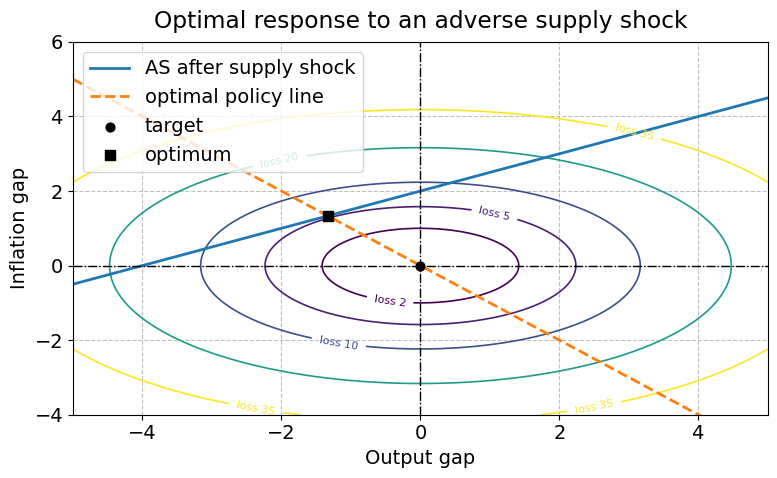

In [6]:
# === Plot the optimal point on the AS curve ===
s_supply = 2.0
x_star, pi_star = optimal_supply_response(par, s_supply)

x_grid = np.linspace(-5, 5, 240)
pi_grid = np.linspace(-4, 6, 240)
X, PI = np.meshgrid(x_grid, pi_grid)
loss_grid = X ** 2 + par['kappa'] * PI ** 2
as_after = par['gamma'] * x_grid + s_supply
policy_line = -x_grid / (par['gamma'] * par['kappa'])

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(1, 1, 1)
levels = [2, 5, 10, 20, 35]
cs = ax.contour(X, PI, loss_grid, levels=levels, linewidths=1.2)
ax.clabel(cs, inline=True, fontsize=8, fmt='loss %.0f')
ax.plot(x_grid, as_after, ls='-', lw=2, label='AS after supply shock')
ax.plot(x_grid, policy_line, ls='--', lw=2, label='optimal policy line')
ax.scatter([0], [0], color='black', marker='o', s=40, label='target', zorder=5)
ax.scatter([x_star], [pi_star], color='black', marker='s', s=55,
           label='optimum', zorder=5)
ax.axhline(0, color='black', lw=1, ls='-.')
ax.axvline(0, color='black', lw=1, ls='-.')
ax.set_title('Optimal response to an adverse supply shock', pad=10)
ax.set_xlabel('Output gap')
ax.set_ylabel('Inflation gap')
ax.set_xlim(-5, 5)
ax.set_ylim(-4, 6)
ax.legend(loc='upper left')
fig.tight_layout()

print(f"Optimal output gap: {x_star:.2f}")
print(f"Optimal inflation gap: {pi_star:.2f}")

The optimum is not the origin because the supply shock has moved the feasible AS curve. The central bank trades a negative output gap against a smaller inflation gap.

In [7]:
# === Sensitivity to the inflation weight ===
kappa_values = np.array([0.25, 0.50, 1.00, 2.00, 4.00, 8.00])
sensitivity_rows = []
for kappa in kappa_values:
    p_tmp = dict(par)
    p_tmp['kappa'] = float(kappa)
    x_opt, pi_opt = optimal_supply_response(p_tmp, s_supply)
    sensitivity_rows.append({'kappa': kappa,
                             'output_gap': x_opt,
                             'inflation_gap': pi_opt,
                             'loss': social_loss(x_opt, pi_opt, p_tmp)})

sensitivity_table = pd.DataFrame(sensitivity_rows)
sensitivity_table.round(3)

,kappa,output_gap,inflation_gap,loss
0,0.25,-0.235,1.882,0.941
1,0.50,-0.444,1.778,1.778
2,1.00,-0.800,1.600,3.200
3,2.00,-1.333,1.333,5.333
4,4.00,-2.000,1.000,8.000
5,8.00,-2.667,0.667,10.667


A higher $\kappa$ lowers the inflation gap and increases the output cost. This is the model's formal version of giving inflation stability more weight.

## 4. <a id='toc4_'></a>[Static expectations and persistence](#toc0_)

With static expectations, current inflation becomes next period's expected inflation. The same one-period shock can therefore leave a persistent inflation gap:

$$\pi_t^e=\pi_{t-1}.$$

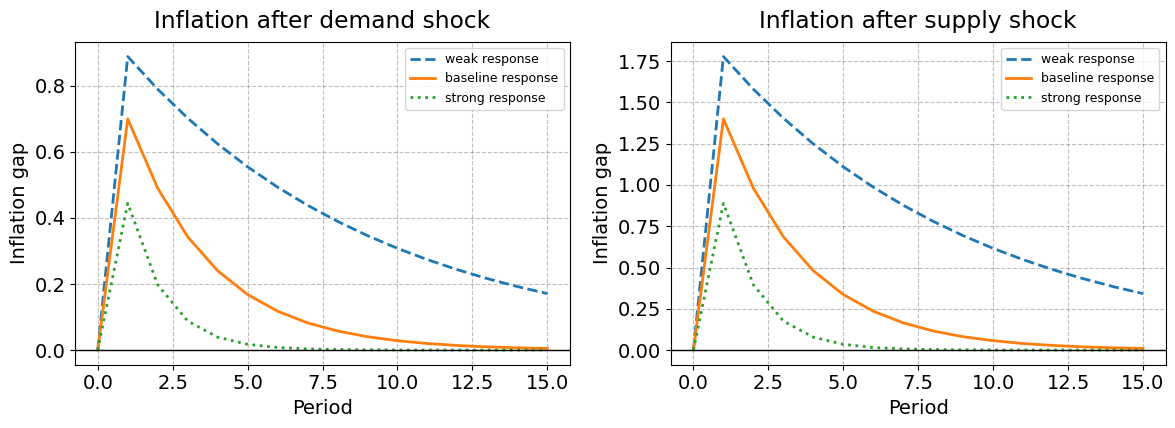

In [8]:
def simulate_static_as_ad(p, z_path, s_path, a):
    '''Simulate AS-AD dynamics with static expectations.'''
    T = len(z_path)
    x = np.empty(T)
    pi_gap = np.empty(T)
    loss_path = np.empty(T)
    for t in range(T):
        pi_e_gap = 0.0 if t == 0 else pi_gap[t - 1]
        x[t], pi_gap[t] = equilibrium_as_ad(p, z=z_path[t], s=s_path[t],
                                            pi_e_gap=pi_e_gap, a=a)
        loss_path[t] = social_loss(x[t], pi_gap[t], p)
    return x, pi_gap, loss_path


# === One-period shocks ===
T = 16
periods = np.arange(T)
z_demand = np.zeros(T)
s_supply = np.zeros(T)
z_demand[1] = 2.0
s_supply[1] = 2.0

paths = []
for label, a_val, ls in [('weak response', 0.25, '--'),
                         ('baseline response', a_base, '-'),
                         ('strong response', 2.50, ':')]:
    x_d, pi_d, loss_d = simulate_static_as_ad(par, z_demand, np.zeros(T), a_val)
    x_s, pi_s, loss_s = simulate_static_as_ad(par, np.zeros(T), s_supply, a_val)
    paths.append((label, a_val, ls, x_d, pi_d, x_s, pi_s))

fig = plt.figure(figsize=(12, 4.5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

for label, a_val, ls, x_d, pi_d, x_s, pi_s in paths:
    ax1.plot(periods, pi_d, ls=ls, lw=2, label=label)
    ax2.plot(periods, pi_s, ls=ls, lw=2, label=label)

for ax, title in zip([ax1, ax2], ['Inflation after demand shock',
                                  'Inflation after supply shock']):
    ax.axhline(0, color='black', lw=1)
    ax.set_title(title, pad=10)
    ax.set_xlabel('Period')
    ax.set_ylabel('Inflation gap')
    ax.legend(fontsize=9)

fig.tight_layout()

The supply shock leaves a larger inflation persistence problem because the shock starts by shifting AS upward. A strong response reduces inflation faster, but the output cost is larger.

## 5. <a id='toc5_'></a>[Real data: Denmark inflation and policy rates](#toc0_)

This section downloads Danish HICP and policy-rate series from FRED when internet access is available. The notebook has an offline fallback so the model sections still run in restricted environments.

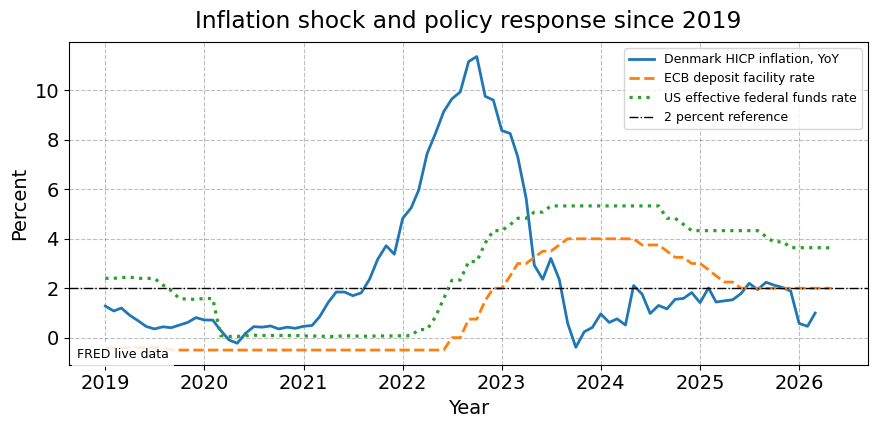

In [9]:
def fetch_fred(series_id, start='2016-01-01'):
    '''Fetch a FRED series through the public graph CSV endpoint.'''
    url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}'
    response = requests.get(url, timeout=20)
    response.raise_for_status()
    df = pd.read_csv(io.StringIO(response.text))
    df['observation_date'] = pd.to_datetime(df['observation_date'])
    s = df.set_index('observation_date')[series_id]
    s = pd.to_numeric(s, errors='coerce').dropna()
    return s[s.index >= pd.Timestamp(start)]


def make_offline_data():
    '''Fallback data with the shape of the recent inflation episode.'''
    idx = pd.date_range('2019-01-01', '2026-03-01', freq='MS')
    t = np.arange(len(idx))
    dk_pi = (1.0
             + 10.5 * np.exp(-0.5 * ((t - 35) / 7.5) ** 2)
             - 1.8 * np.exp(-0.5 * ((t - 49) / 3.5) ** 2)
             + 0.8 * np.exp(-0.5 * ((t - 69) / 6.0) ** 2))
    ecb = np.piecewise(
        t,
        [t < 30, (t >= 30) & (t < 42), (t >= 42) & (t < 63), t >= 63],
        [-0.5, lambda x: -0.5 + (x - 30) * 0.25,
         lambda x: 2.5 + (x - 42) * 0.07,
         lambda x: 4.0 - (x - 63) * 0.12],
    )
    fed = np.piecewise(
        t,
        [t < 26, (t >= 26) & (t < 31), (t >= 31) & (t < 54), t >= 54],
        [1.5, 0.1, lambda x: 0.1 + (x - 31) * 0.23,
         lambda x: 5.4 - (x - 54) * 0.08],
    )
    return pd.DataFrame({'dk_pi': dk_pi, 'ECBDFR': ecb, 'EFFR': fed}, index=idx)


try:
    hicp = fetch_fred('CP0000DKM086NEST', start='2016-01-01')
    dk_pi = hicp.pct_change(12) * 100
    ecb_rate = fetch_fred('ECBDFR', start='2019-01-01').resample('MS').last()
    fed_rate = fetch_fred('EFFR', start='2019-01-01').resample('MS').last()
    data = pd.concat([dk_pi.rename('dk_pi'), ecb_rate.rename('ECBDFR'),
                      fed_rate.rename('EFFR')], axis=1)
    data = data[data.index >= '2019-01-01'].dropna(how='all')
    data_source = 'FRED live data'
except Exception as exc:
    print(f'FRED download failed, using offline fallback: {exc}')
    data = make_offline_data()
    data_source = 'offline fallback, rerun online for live data'

fig = plt.figure(figsize=(9, 4.5))
ax = fig.add_subplot(1, 1, 1)
ax.plot(data.index, data['dk_pi'], ls='-', lw=2.0,
        label='Denmark HICP inflation, YoY')
ax.plot(data.index, data['ECBDFR'], ls='--', lw=2.0,
        label='ECB deposit facility rate')
ax.plot(data.index, data['EFFR'], ls=':', lw=2.3,
        label='US effective federal funds rate')
ax.axhline(2.0, color='black', lw=1, ls='-.', label='2 percent reference')
ax.set_title('Inflation shock and policy response since 2019', pad=10)
ax.set_xlabel('Year')
ax.set_ylabel('Percent')
ax.legend(loc='upper right', fontsize=9)
ax.text(0.01, 0.02, data_source, transform=ax.transAxes, fontsize=9,
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))
fig.tight_layout()

When the live data are available, the plot uses FRED series `CP0000DKM086NEST`, `ECBDFR`, and `EFFR`. The model interpretation is that a supply-driven inflation surge raises the cost of disinflation because demand must be cooled to reduce inflation pressure.

## 6. <a id='toc6_'></a>[Fiscal policy at the lower bound](#toc0_)

In normal times, fiscal expansion is partly offset by tighter monetary policy. At the lower bound, the nominal rate cannot rise in response, so the fiscal multiplier can be larger.

Normal-times output multiplier: 0.71
Liquidity-trap output multiplier: 1.92


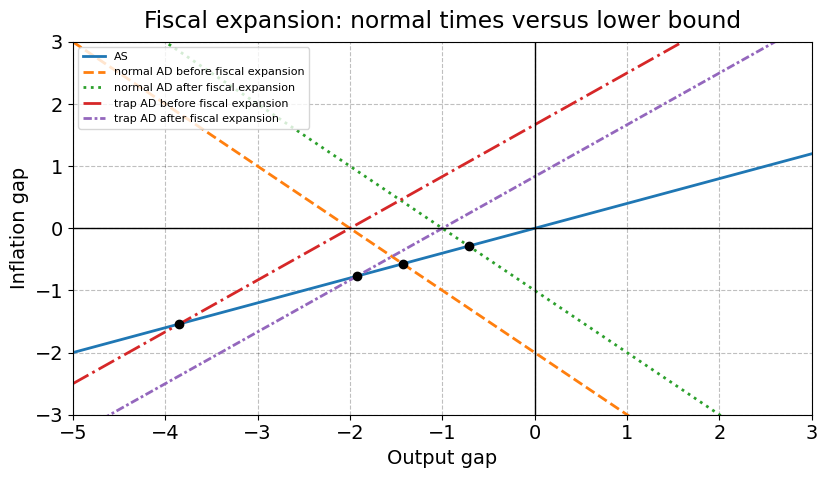

In [10]:
# === Normal AD versus trap AD ===
trap_par = {
    'gamma': 0.40,
    'alpha2': 1.20,
    'a_normal': 1.00,
    'v_bust': -2.0,
    'Delta': 1.0,
}

def solve_normal_fiscal(p, Delta):
    '''Solve normal-times fiscal expansion with AS pi = gamma*x.'''
    shift = p['v_bust'] + Delta
    x = shift / (1.0 + p['a_normal'] * p['gamma'])
    pi_gap = p['gamma'] * x
    return x, pi_gap


def solve_trap_fiscal(p, Delta):
    '''Solve trap equilibrium with upward-sloping AD.'''
    shift = p['v_bust'] + Delta
    x = shift / (1.0 - p['alpha2'] * p['gamma'])
    pi_gap = p['gamma'] * x
    return x, pi_gap


x0_n, pi0_n = solve_normal_fiscal(trap_par, Delta=0.0)
x1_n, pi1_n = solve_normal_fiscal(trap_par, Delta=trap_par['Delta'])
x0_t, pi0_t = solve_trap_fiscal(trap_par, Delta=0.0)
x1_t, pi1_t = solve_trap_fiscal(trap_par, Delta=trap_par['Delta'])

mult_normal = (x1_n - x0_n) / trap_par['Delta']
mult_trap = (x1_t - x0_t) / trap_par['Delta']
print(f"Normal-times output multiplier: {mult_normal:.2f}")
print(f"Liquidity-trap output multiplier: {mult_trap:.2f}")

x_grid = np.linspace(-5, 3, 200)
fig = plt.figure(figsize=(8.5, 5))
ax = fig.add_subplot(1, 1, 1)
ax.plot(x_grid, trap_par['gamma'] * x_grid, ls='-', lw=2, label='AS')

# AD normal: x = shift - a*pi, so pi = (shift - x)/a
for Delta, ls, label in [(0.0, '--', 'normal AD before fiscal expansion'),
                         (trap_par['Delta'], ':', 'normal AD after fiscal expansion')]:
    shift = trap_par['v_bust'] + Delta
    ax.plot(x_grid, (shift - x_grid) / trap_par['a_normal'],
            ls=ls, lw=2, label=label)

# AD trap: x = shift + alpha2*pi, so pi = (x - shift)/alpha2
for Delta, ls, label in [(0.0, '-.', 'trap AD before fiscal expansion'),
                         (trap_par['Delta'], (0, (3, 1, 1, 1)), 'trap AD after fiscal expansion')]:
    shift = trap_par['v_bust'] + Delta
    ax.plot(x_grid, (x_grid - shift) / trap_par['alpha2'],
            ls=ls, lw=2, label=label)

ax.scatter([x0_n, x1_n, x0_t, x1_t], [pi0_n, pi1_n, pi0_t, pi1_t],
           color='black', zorder=5)
ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='black', lw=1)
ax.set_title('Fiscal expansion: normal times versus lower bound', pad=10)
ax.set_xlabel('Output gap')
ax.set_ylabel('Inflation gap')
ax.set_xlim(-5, 3)
ax.set_ylim(-3, 3)
ax.legend(fontsize=8, loc='upper left')
fig.tight_layout()

The fiscal expansion shifts demand in both regimes. The lower-bound case has the larger output effect because the interest-rate offset is absent and higher inflation lowers the real rate.

## 7. <a id='toc7_'></a>[Group exercise](#toc0_)

Work in small groups. Use the cells below to compute the answer, then submit one short text response in Socrative.

A supply shock hits the economy: $s_t=2$. Use $\gamma=0.5$ and $\kappa=2$.

1. Compute the optimal output gap and inflation gap.
2. Compare this optimum with a weak Taylor-rule response, $a=0.25$, and a strong response, $a=2.5$.
3. Submit one sentence: which response has the lowest loss, and what is the economic mechanism?

In [11]:
# === Group exercise scaffold ===
group_par = {
    'gamma': 0.50,
    'kappa': 2.00,
    'alpha2': 1.50,
    'h': 1.00,
    'b': 0.50,
}
group_s = 2.0

x_opt, pi_opt = optimal_supply_response(group_par, group_s)
weak_x, weak_pi = equilibrium_as_ad(group_par, s=group_s, a=0.25)
strong_x, strong_pi = equilibrium_as_ad(group_par, s=group_s, a=2.50)

exercise_result = pd.DataFrame({
    'response': ['optimal', 'weak Taylor-rule response', 'strong Taylor-rule response'],
    'output_gap': [x_opt, weak_x, strong_x],
    'inflation_gap': [pi_opt, weak_pi, strong_pi],
    'loss': [social_loss(x_opt, pi_opt, group_par),
             social_loss(weak_x, weak_pi, group_par),
             social_loss(strong_x, strong_pi, group_par)],
})
exercise_result.round(3)

,response,output_gap,inflation_gap,loss
0,optimal,-1.333,1.333,5.333
1,weak Taylor-rule response,-0.444,1.778,6.519
2,strong Taylor-rule response,-2.222,0.889,6.519


The answer should connect the numbers to the mechanism: reducing inflation after a supply shock requires a negative output gap, and the best response balances the two losses.

## 8. <a id='toc8_'></a>[Summary](#toc0_)

| Object | Equation | Interpretation |
|---|---|---|
| Social loss | $SL_t=\widehat y_t^2+\kappa\widehat\pi_t^2$ | Policy cares about both gaps. |
| Taylor-rule AD | $\widehat y_t=z_t-a\widehat\pi_t$ | Inflation raises rates and lowers demand. |
| AD slope parameter | $a=\alpha_2h/(1+\alpha_2b)$ | Larger $h$ makes AD flatter, larger $b$ dampens shocks. |
| AS curve | $\widehat\pi_t=\pi_t^e-\pi^*+\gamma\widehat y_t+s_t$ | Output gaps and supply shocks move inflation. |
| Optimal supply response | $\widehat y_t^*=-\gamma\kappa s_t/(1+\gamma^2\kappa)$ | Higher $\kappa$ lowers inflation at an output cost. |
| Lower-bound AD | $\widehat y_t=\Delta_t+\alpha_2(\pi_t+\bar r)+v_t$ | Fiscal policy is not offset by rate hikes in the trap. |

For exam-style answers, always state the shock, identify whether AD or AS moves, and explain why the policy trade-off does or does not appear.